In [1]:
%pip -q install "datasets==3.6.0" torchaudio tqdm
import datasets
print("datasets:", datasets.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 8.3 MB/s eta 0:00:00
datasets: 3.6.0


In [2]:
%pip -q install scikit-learn seaborn


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os, glob, torch

SAVE_ROOT = "/content/drive/MyDrive/fleurs_preprocessed/eastern_european"
train_shards = os.path.join(SAVE_ROOT, "train_shards")
val_shards   = os.path.join(SAVE_ROOT, "validation_shards")
test_shards  = os.path.join(SAVE_ROOT, "test_shards")


Mounted at /content/drive


# Load Data

In [4]:
def load_sharded_dataset(shard_dir, prefix):
    files = sorted(glob.glob(os.path.join(shard_dir, f"{prefix}_shard_*.pt")))
    all_data = []
    for f in files:
        all_data.extend(torch.load(f, weights_only=False))
    return all_data

train_data = load_sharded_dataset(train_shards, "train")
val_data   = load_sharded_dataset(val_shards, "validation")
test_data  = load_sharded_dataset(test_shards, "test")

print("Train:", len(train_data), "Val:", len(val_data), "Test:", len(test_data))
print("Example:", train_data[0]["x"].shape, train_data[0]["y"], train_data[0]["language"])


Train: 23856 Val: 4640 Test: 10528
Example: torch.Size([1057, 80]) 3 Czech


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

class PreprocessedDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        return item["x"], item["y"]  # x: [T,80], y: int

def collate_fnn(batch):
    xs, ys = zip(*batch)
    pooled = [x.mean(dim=0) for x in xs]         # [80]
    X = torch.stack(pooled, dim=0)               # [B,80]
    y = torch.tensor(ys, dtype=torch.long)       # [B]
    return X, y


In [6]:
BATCH_SIZE = 256

train_loader_fnn = DataLoader(PreprocessedDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fnn)
val_loader_fnn   = DataLoader(PreprocessedDataset(val_data),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fnn)
test_loader_fnn  = DataLoader(PreprocessedDataset(test_data),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fnn)

X, y = next(iter(train_loader_fnn))
print("X:", X.shape, "y:", y.shape)


X: torch.Size([256, 80]) y: torch.Size([256])


In [7]:
import torch.nn as nn

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader, criterion, device, return_preds=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
    if return_preds:
        return total_loss/total, correct/total, torch.cat(all_labels).numpy(), torch.cat(all_preds).numpy()
    return total_loss/total, correct/total


# Baseline FNN Model

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

NUM_CLASSES = 16

class FNNBaseline(nn.Module):
    def __init__(self, input_dim=80, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )
    def forward(self, x): return self.net(x)

model_base = FNNBaseline(num_classes=NUM_CLASSES, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_base.parameters(), lr=1e-3)


device: cpu


In [9]:
history_base = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
num_epochs = 10

for epoch in range(1, num_epochs+1):
    tr_loss, tr_acc = train_one_epoch(model_base, train_loader_fnn, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_base, val_loader_fnn, criterion, device)

    history_base["train_loss"].append(tr_loss)
    history_base["train_acc"].append(tr_acc)
    history_base["val_loss"].append(va_loss)
    history_base["val_acc"].append(va_acc)

    print(f"[BASE] Epoch {epoch:02d}/{num_epochs} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")


[BASE] Epoch 01/10 | train_loss=2.8522 train_acc=0.0819 | val_loss=2.8297 val_acc=0.0608
[BASE] Epoch 02/10 | train_loss=2.6203 train_acc=0.1359 | val_loss=2.9686 val_acc=0.0733
[BASE] Epoch 03/10 | train_loss=2.4218 train_acc=0.2181 | val_loss=3.3125 val_acc=0.0905
[BASE] Epoch 04/10 | train_loss=2.1842 train_acc=0.2810 | val_loss=3.6451 val_acc=0.1013
[BASE] Epoch 05/10 | train_loss=1.9880 train_acc=0.3462 | val_loss=3.9270 val_acc=0.1196
[BASE] Epoch 06/10 | train_loss=1.8332 train_acc=0.3984 | val_loss=4.0585 val_acc=0.1080
[BASE] Epoch 07/10 | train_loss=1.7168 train_acc=0.4408 | val_loss=4.0722 val_acc=0.0989
[BASE] Epoch 08/10 | train_loss=1.6498 train_acc=0.4690 | val_loss=4.2306 val_acc=0.1172
[BASE] Epoch 09/10 | train_loss=1.5762 train_acc=0.4927 | val_loss=4.5356 val_acc=0.1015
[BASE] Epoch 10/10 | train_loss=1.5314 train_acc=0.5039 | val_loss=4.3464 val_acc=0.1099


In [10]:
te_loss, te_acc = evaluate(model_base, test_loader_fnn, criterion, device)
print(f"[BASE] TEST | loss={te_loss:.4f} acc={te_acc:.4f}")


[BASE] TEST | loss=4.2984 acc=0.1127


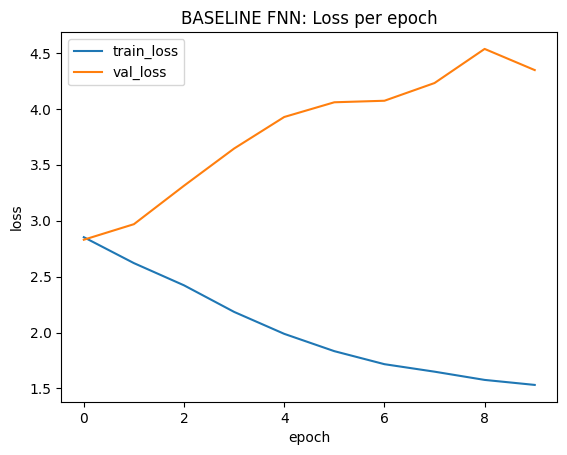

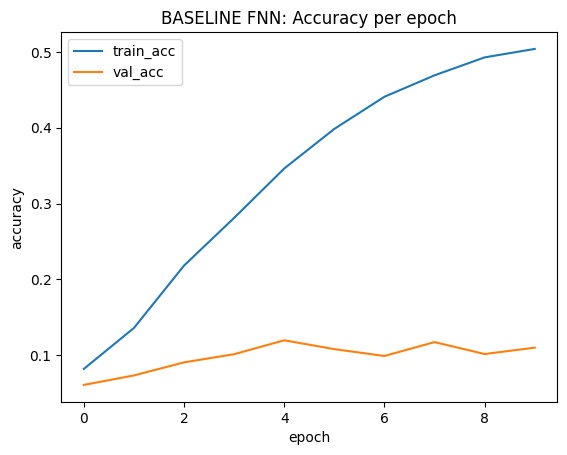

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_base["train_loss"], label="train_loss")
plt.plot(history_base["val_loss"], label="val_loss")
plt.legend()
plt.title("BASELINE FNN: Loss per epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(history_base["train_acc"], label="train_acc")
plt.plot(history_base["val_acc"], label="val_acc")
plt.legend()
plt.title("BASELINE FNN: Accuracy per epoch")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.show()


# Upgraded FNN (BatchNorm + AdamW)

In [13]:
class FNN_BN(nn.Module):
    def __init__(self, input_dim=80, num_classes=NUM_CLASSES, dropout=0.35):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )
    def forward(self, x): return self.net(x)

model_up = FNN_BN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_up.parameters(), lr=3e-4, weight_decay=1e-2)


In [14]:
import copy

history_up = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
num_epochs = 30
best_val_acc, best_epoch, best_state = -1.0, -1, None

for epoch in range(1, num_epochs+1):
    tr_loss, tr_acc = train_one_epoch(model_up, train_loader_fnn, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_up, val_loader_fnn, criterion, device)

    history_up["train_loss"].append(tr_loss)
    history_up["train_acc"].append(tr_acc)
    history_up["val_loss"].append(va_loss)
    history_up["val_acc"].append(va_acc)

    print(f"[UP] Epoch {epoch:02d}/{num_epochs} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc, best_epoch = va_acc, epoch
        best_state = copy.deepcopy(model_up.state_dict())
        print(f"  ✅ best val_acc={best_val_acc:.4f} at epoch {best_epoch}")

model_up.load_state_dict(best_state)
print(f"Restored best checkpoint: epoch={best_epoch}, val_acc={best_val_acc:.4f}")


[UP] Epoch 01/30 | train_loss=2.3207 train_acc=0.3022 | val_loss=2.9202 val_acc=0.0922
  ✅ best val_acc=0.0922 at epoch 1
[UP] Epoch 02/30 | train_loss=1.6534 train_acc=0.5618 | val_loss=3.0770 val_acc=0.1425
  ✅ best val_acc=0.1425 at epoch 2
[UP] Epoch 03/30 | train_loss=1.2122 train_acc=0.6979 | val_loss=3.0896 val_acc=0.1534
  ✅ best val_acc=0.1534 at epoch 3
[UP] Epoch 04/30 | train_loss=0.9216 train_acc=0.7687 | val_loss=3.2722 val_acc=0.1616
  ✅ best val_acc=0.1616 at epoch 4
[UP] Epoch 05/30 | train_loss=0.7348 train_acc=0.8125 | val_loss=3.5913 val_acc=0.1621
  ✅ best val_acc=0.1621 at epoch 5
[UP] Epoch 06/30 | train_loss=0.6108 train_acc=0.8414 | val_loss=3.6102 val_acc=0.1534
[UP] Epoch 07/30 | train_loss=0.5152 train_acc=0.8620 | val_loss=3.8037 val_acc=0.1532
[UP] Epoch 08/30 | train_loss=0.4529 train_acc=0.8766 | val_loss=3.8514 val_acc=0.1597
[UP] Epoch 09/30 | train_loss=0.3982 train_acc=0.8906 | val_loss=4.1722 val_acc=0.1338
[UP] Epoch 10/30 | train_loss=0.3640 train

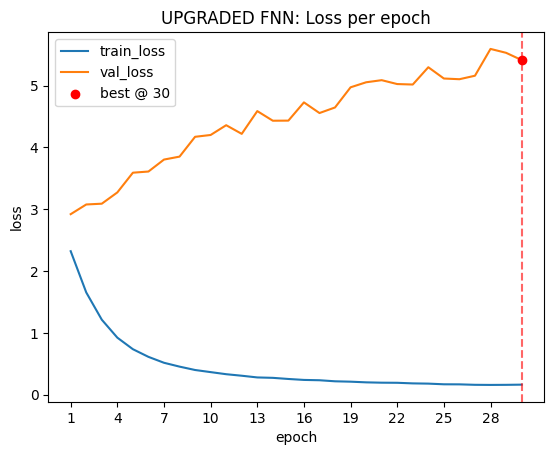

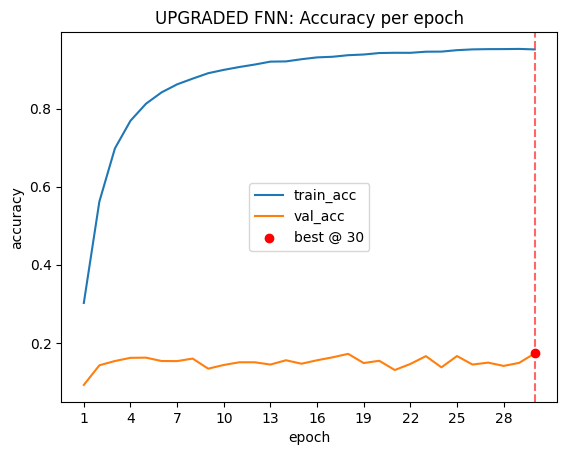

In [16]:
import matplotlib.pyplot as plt

num_epochs = len(history_up["train_loss"])
epochs = list(range(1, num_epochs + 1))

plt.figure()
plt.plot(epochs, history_up["train_loss"], label="train_loss")
plt.plot(epochs, history_up["val_loss"], label="val_loss")
plt.scatter([best_epoch], [history_up["val_loss"][best_epoch-1]], color="red", zorder=5, label=f"best @ {best_epoch}")
plt.axvline(best_epoch, color="red", linestyle="--", alpha=0.6)
plt.legend()
plt.title("UPGRADED FNN: Loss per epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.xticks(range(1, num_epochs+1, max(1, num_epochs//10)))
plt.show()

plt.figure()
plt.plot(epochs, history_up["train_acc"], label="train_acc")
plt.plot(epochs, history_up["val_acc"], label="val_acc")
plt.scatter([best_epoch], [history_up["val_acc"][best_epoch-1]], color="red", zorder=5, label=f"best @ {best_epoch}")
plt.axvline(best_epoch, color="red", linestyle="--", alpha=0.6)
plt.legend()
plt.title("UPGRADED FNN: Accuracy per epoch")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.xticks(range(1, num_epochs+1, max(1, num_epochs//10)))
plt.show()


val accuracy is noisy (because val set is only 900 examples total) aka overfitting

This figure shows the learning curves for the upgraded feed-forward network trained for 30 epochs on the Eastern European subset. The training loss steadily decreases and the training accuracy rapidly increases, indicating the model is fitting the training data very well. However, the validation loss increases over time while validation accuracy stays low and noisy, which is a classic sign of overfitting: the model becomes more confident on the training set but does not generalize well to unseen validation examples. The red marker highlights the checkpoint chosen as “best” by validation accuracy (epoch 30).

# More meaningfull model

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 16  # Eastern European

model_up2 = FNN_BN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model_up2.parameters(), lr=1e-4, weight_decay=2e-2)

print("device:", device)
print("optimizer: AdamW lr=1e-4 weight_decay=2e-2")


device: cpu
optimizer: AdamW lr=1e-4 weight_decay=2e-2


In [18]:
import copy

history_up2 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
num_epochs = 60

best_val_acc, best_epoch, best_state = -1.0, -1, None

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model_up2, train_loader_fnn, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_up2, val_loader_fnn, criterion, device)

    history_up2["train_loss"].append(tr_loss)
    history_up2["train_acc"].append(tr_acc)
    history_up2["val_loss"].append(va_loss)
    history_up2["val_acc"].append(va_acc)

    print(f"[UP2] Epoch {epoch:02d}/{num_epochs} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc, best_epoch = va_acc, epoch
        best_state = copy.deepcopy(model_up2.state_dict())
        print(f"  ✅ best val_acc={best_val_acc:.4f} at epoch {best_epoch}")

model_up2.load_state_dict(best_state)
print(f"\nRestored best checkpoint: epoch={best_epoch}, val_acc={best_val_acc:.4f}")


[UP2] Epoch 01/60 | train_loss=2.6111 train_acc=0.1750 | val_loss=2.8301 val_acc=0.0791
  ✅ best val_acc=0.0791 at epoch 1
[UP2] Epoch 02/60 | train_loss=2.2571 train_acc=0.3357 | val_loss=2.8689 val_acc=0.0940
  ✅ best val_acc=0.0940 at epoch 2
[UP2] Epoch 03/60 | train_loss=2.0046 train_acc=0.4392 | val_loss=2.9192 val_acc=0.1017
  ✅ best val_acc=0.1017 at epoch 3
[UP2] Epoch 04/60 | train_loss=1.7849 train_acc=0.5234 | val_loss=2.9692 val_acc=0.1205
  ✅ best val_acc=0.1205 at epoch 4
[UP2] Epoch 05/60 | train_loss=1.5874 train_acc=0.5900 | val_loss=3.0214 val_acc=0.1203
[UP2] Epoch 06/60 | train_loss=1.4124 train_acc=0.6465 | val_loss=3.1010 val_acc=0.1416
  ✅ best val_acc=0.1416 at epoch 6
[UP2] Epoch 07/60 | train_loss=1.2611 train_acc=0.6878 | val_loss=3.1447 val_acc=0.1481
  ✅ best val_acc=0.1481 at epoch 7
[UP2] Epoch 08/60 | train_loss=1.1257 train_acc=0.7260 | val_loss=3.1735 val_acc=0.1506
  ✅ best val_acc=0.1506 at epoch 8
[UP2] Epoch 09/60 | train_loss=1.0109 train_acc=0.7

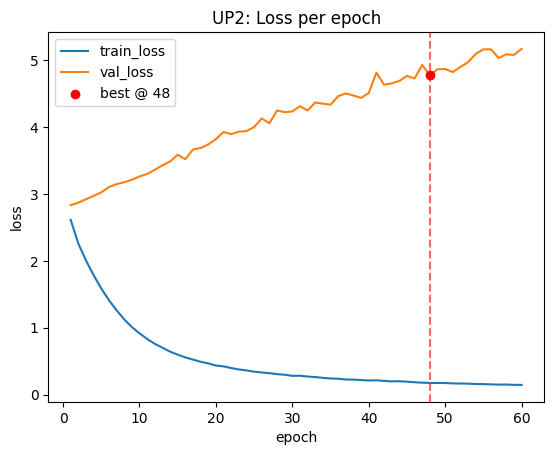

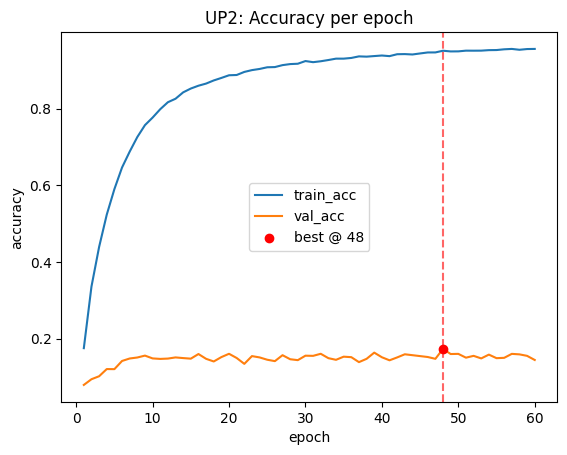

In [19]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history_up2["train_loss"]) + 1))

plt.figure()
plt.plot(epochs, history_up2["train_loss"], label="train_loss")
plt.plot(epochs, history_up2["val_loss"], label="val_loss")
plt.scatter([best_epoch], [history_up2["val_loss"][best_epoch-1]], color="red", zorder=5, label=f"best @ {best_epoch}")
plt.axvline(best_epoch, color="red", linestyle="--", alpha=0.6)
plt.legend()
plt.title("UP2: Loss per epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(epochs, history_up2["train_acc"], label="train_acc")
plt.plot(epochs, history_up2["val_acc"], label="val_acc")
plt.scatter([best_epoch], [history_up2["val_acc"][best_epoch-1]], color="red", zorder=5, label=f"best @ {best_epoch}")
plt.axvline(best_epoch, color="red", linestyle="--", alpha=0.6)
plt.legend()
plt.title("UP2: Accuracy per epoch")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.show()


This figure shows the same upgraded architecture trained longer (60 epochs) with a smaller learning rate and stronger weight decay. Training still improves consistently (loss decreases, accuracy increases), but the validation loss continues to rise and validation accuracy remains relatively flat, meaning generalization is still limited. The best validation accuracy occurs around epoch 48 (red marker), suggesting that longer training did not eliminate overfitting; it mostly improved training fit while validation performance stayed constrained.

[UP2] TEST | loss=4.7335 acc=0.1776 (sklearn acc=0.1776)


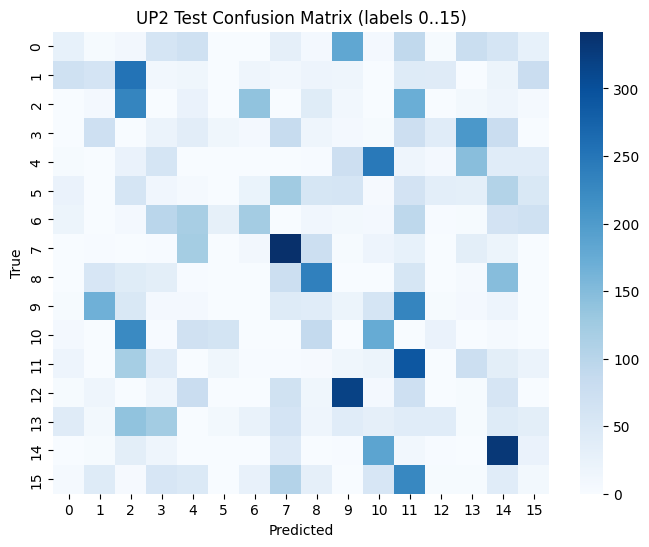

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

te_loss, te_acc, y_true, y_pred = evaluate(model_up2, test_loader_fnn, criterion, device, return_preds=True)
print(f"[UP2] TEST | loss={te_loss:.4f} acc={te_acc:.4f} (sklearn acc={accuracy_score(y_true, y_pred):.4f})")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("UP2 Test Confusion Matrix (labels 0..15)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


This figure shows the test-set confusion matrix for the UP2 model on 16 Eastern European languages (labels 0–15). Darker diagonal cells indicate correct classifications; off-diagonal darker blocks show systematic confusions between certain language pairs. The reported test accuracy is ~0.1776, which is above random chance for 16 classes (~0.0625), but still low overall. The matrix suggests the model learns some language-specific patterns but frequently confuses languages with similar acoustic/phonological characteristics, consistent with the weak validation performance.